<a href="https://colab.research.google.com/github/Dishabh13/5A_B-PR-Demo/blob/main/AIML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import random, time, heapq, itertools
from collections import deque, defaultdict

GOAL = (1,2,3,4,5,6,7,8,0)
MOVES = {0:(1,3),1:(0,2,4),2:(1,5),3:(0,4,6),4:(1,3,5,7),
         5:(2,4,8),6:(3,7),7:(4,6,8),8:(5,7)}

def is_solvable(state):
    arr = [x for x in state if x!=0]
    inv = sum(1 for i in range(len(arr)) for j in range(i+1,len(arr)) if arr[i]>arr[j])
    return inv % 2 == 0

def neighbors(state):
    z = state.index(0)
    for nb in MOVES[z]:
        s = list(state)
        s[z], s[nb] = s[nb], s[z]
        yield tuple(s), 1

def random_start(max_shuffles=60):
    s = list(GOAL); z = s.index(0)
    for _ in range(random.randint(20,max_shuffles)):
        nb = random.choice(MOVES[z])
        s[z], s[nb] = s[nb], s[z]; z = nb
    return tuple(s)

class Result:
    def __init__(self, found, path_cost, nodes_expanded, depth, secs, path):
        self.found=found; self.path_cost=path_cost
        self.nodes_expanded=nodes_expanded; self.depth=depth
        self.secs=secs; self.path=path

def reconstruct(parents, s):
    path=[s]
    while s in parents:
        s=parents[s]; path.append(s)
    path.reverse(); return path

def run_search(start, algo="bfs", heuristic=None):
    t0=time.perf_counter(); nodes_expanded=0
    if start==GOAL:
        return Result(True,0,0,0,0.0,[start])

    if algo=="bfs":
        Q=deque([start]); parents={}; seen={start}
        while Q:
            s=Q.popleft(); nodes_expanded+=1
            for nxt,_ in neighbors(s):
                if nxt in seen: continue
                parents[nxt]=s; seen.add(nxt)
                if nxt==GOAL:
                    path=reconstruct(parents,nxt)
                    return Result(True,len(path)-1,nodes_expanded,len(path)-1,time.perf_counter()-t0,path)
                Q.append(nxt)
        return Result(False,-1,nodes_expanded,-1,time.perf_counter()-t0,[])

    if algo=="dfs":
        stack=[start]; parents={}; seen={start}
        while stack:
            s=stack.pop(); nodes_expanded+=1
            for nxt,_ in neighbors(s):
                if nxt in seen: continue
                parents[nxt]=s; seen.add(nxt)
                if nxt==GOAL:
                    path=reconstruct(parents,nxt)
                    return Result(True,len(path)-1,nodes_expanded,len(path)-1,time.perf_counter()-t0,path)
                stack.append(nxt)
        return Result(False,-1,nodes_expanded,-1,time.perf_counter()-t0,[])

    if algo in ("ucs","astar"):
        g=defaultdict(lambda: float("inf")); g[start]=0
        parents={}; cnt=itertools.count()
        def h(s): return 0 if heuristic is None else heuristic(s)
        open_heap=[(g[start]+h(start), next(cnt), start)]; closed=set()
        while open_heap:
            f,_,s=heapq.heappop(open_heap)
            if s in closed: continue
            closed.add(s); nodes_expanded+=1
            if s==GOAL:
                path=reconstruct(parents,s)
                return Result(True,g[s],nodes_expanded,len(path)-1,time.perf_counter()-t0,path)
            for nxt,c in neighbors(s):
                tentative=g[s]+c
                if tentative<g[nxt]:
                    g[nxt]=tentative; parents[nxt]=s
                    heapq.heappush(open_heap,(tentative+(0 if algo=="ucs" else h(nxt)), next(cnt), nxt))
        return Result(False,-1,nodes_expanded,-1,time.perf_counter()-t0,[])

    raise ValueError("Unknown algo")

goal_pos={v:i for i,v in enumerate(GOAL)}

def manhattan(s):
    dist=0
    for idx,val in enumerate(s):
        if val==0: continue
        gi=goal_pos[val]; r1,c1=divmod(idx,3); r2,c2=divmod(gi,3)
        dist+=abs(r1-r2)+abs(c1-c2)
    return dist

def linear_conflict(s):
    dist=manhattan(s)
    for r in range(3):
        row=s[3*r:3*r+3]; goal_row=[1+3*r,2+3*r,3+3*r]
        tiles=[x for x in row if x in goal_row]
        for i in range(len(tiles)):
            for j in range(i+1,len(tiles)):
                if goal_row.index(tiles[i])>goal_row.index(tiles[j]): dist+=2
    for c in range(3):
        col=s[c::3]; goal_col=[c+1,c+4,c+7]
        tiles=[x for x in col if x in goal_col]
        for i in range(len(tiles)):
            for j in range(i+1,len(tiles)):
                if goal_col.index(tiles[i])>goal_col.index(tiles[j]): dist+=2
    return dist

def run_experiments(num=5, seed=7):
    random.seed(seed); starts=[]
    while len(starts)<num:
        s=random_start()
        if is_solvable(s) and s not in starts: starts.append(s)
    rows=[]
    for i,s in enumerate(starts,1):
        for algo in ["bfs","dfs","ucs"]:
            res=run_search(s,algo=algo)
            rows.append(("Case"+str(i),algo.upper(),res.path_cost,res.nodes_expanded,res.secs))
        for name,h in [("A*-Manhattan",manhattan),("A*-LinearConflict",linear_conflict)]:
            res=run_search(s,algo="astar",heuristic=h)
            rows.append(("Case"+str(i),name,res.path_cost,res.nodes_expanded,res.secs))
    return rows

if __name__=="__main__":
    from pprint import pprint
    rows=run_experiments()
    print("Case,Method,PathCost,NodesExpanded,Time(s)")
    for r in rows: print(",".join([str(x) for x in r]))

    import statistics as st
    def agg(label):
        subset=[r for r in rows if r[1]==label]
        return st.mean([r[3] for r in subset]), st.mean([r[4] for r in subset])
    u_nodes,u_time=agg("UCS")
    m_nodes,m_time=agg("A*-Manhattan")
    l_nodes,l_time=agg("A*-LinearConflict")
    print("\\nAverages over 5 starts:")
    print(f"UCS  : nodes={u_nodes:.0f}, time={u_time:.4f}s")
    print(f"A* M : nodes={m_nodes:.0f}, time={m_time:.4f}s")
    print(f"A* LC: nodes={l_nodes:.0f}, time={l_time:.4f}s")

Case,Method,PathCost,NodesExpanded,Time(s)
Case1,BFS,10,371,0.0007560190000504008
Case1,DFS,20688,23224,0.05114216800006943
Case1,UCS,10,601,0.001981158000035066
Case1,A*-Manhattan,10,26,0.0002569870000570518
Case1,A*-LinearConflict,10,23,0.0004233109999631779
Case2,BFS,4,13,3.172100002757361e-05
Case2,DFS,214,232,0.00043629800006783626
Case2,UCS,4,27,9.03670000980128e-05
Case2,A*-Manhattan,4,5,4.5268999997460924e-05
Case2,A*-LinearConflict,4,5,0.00011660600000595878
Case3,BFS,20,34664,0.08130943799994839
Case3,DFS,22492,25224,0.05665500099996734
Case3,UCS,20,50118,0.2584500200000548
Case3,A*-Manhattan,20,756,0.01267216600001575
Case3,A*-LinearConflict,20,437,0.013198042999988502
Case4,BFS,17,9418,0.03236401399999522
Case4,DFS,47999,54877,0.23630078200005755
Case4,UCS,17,14346,0.10688161000007312
Case4,A*-Manhattan,17,80,0.00119065799992768
Case4,A*-LinearConflict,17,63,0.00190361300008135
Case5,BFS,4,14,5.5174999943119474e-05
Case5,DFS,46136,52626,0.22003839400008474
Case5,UCS,4,29,0.

In [ ]:

from collections import deque
from itertools import product

DIRS=[(1,0),(-1,0),(0,1),(0,-1)]
def in_bounds(x,y): return 1<=x<=4 and 1<=y<=4
def neighbors(x,y):
    for dx,dy in DIRS:
        nx,ny=x+dx,y+dy
        if in_bounds(nx,ny): yield (nx,ny)

class KB:
    def __init__(self):
        self.safe=set(); self.pit=set(); self.possible={}; self.logs=[]
    def assert_no_breeze(self,x,y):
        for n in neighbors(x,y):
            if n not in self.safe and n not in self.pit:
                self.safe.add(n)
                self.logs.append(f"From ¬B({x},{y}) infer SAFE{n}")
    def assert_breeze(self,x,y):
        if (x,y) not in self.possible:
            cands={n for n in neighbors(x,y) if n not in self.safe and n not in self.pit}
            self.possible[(x,y)]=cands
            self.logs.append(f"B({x},{y}) ⇒ one of {sorted(cands)} is a Pit")
    def mark_safe(self,cell):
        if cell in self.safe: return
        self.safe.add(cell)
        for k in list(self.possible):
            if cell in self.possible[k]:
                self.possible[k].remove(cell)
                self.logs.append(f"{cell} SAFE ⇒ remove from pit-candidates of {k}")
    def deduce(self):
        changed=True
        while changed:
            changed=False
            for k,cands in list(self.possible.items()):
                cands={c for c in cands if c not in self.safe and c not in self.pit}
                self.possible[k]=cands
                if len(cands)==1:
                    p=next(iter(cands))
                    if p not in self.pit:
                        self.pit.add(p); changed=True
                        self.logs.append(f"Only {p} fits B{tuple(k)} ⇒ PIT{p}")

class World:
    def __init__(self,pits={(3,1)},wumpus=(4,3),gold=(2,3)):
        self.pits=set(pits); self.wumpus=wumpus; self.gold=gold
    def percept(self,x,y):
        breeze=any(n in self.pits for n in neighbors(x,y))
        stench=any(n==self.wumpus for n in neighbors(x,y))
        glitter=(x,y)==self.gold
        return {"breeze":breeze,"stench":stench,"glitter":glitter}

def agent_run(world,start=(1,1)):
    kb=KB(); path=[start]; visited={start}; have_gold=False
    def process(c):
        nonlocal have_gold
        x,y=c; p=world.percept(x,y)
        if p["glitter"]: have_gold=True; kb.logs.append(f"GLITTER at {c} ⇒ grab gold")
        if p["breeze"]: kb.assert_breeze(x,y)
        else: kb.assert_no_breeze(x,y)
        kb.mark_safe(c); kb.deduce()
    process(start)
    while True:
        options=[n for n in neighbors(*path[-1]) if n in kb.safe and n not in visited]
        if not options: break
        nxt=sorted(options)[0]
        path.append(nxt); visited.add(nxt)
        process(nxt)
        if have_gold and nxt==(1,1): break
        if have_gold and nxt!=(1,1):
            def manhattan(a,b): return abs(a[0]-b[0])+abs(a[1]-b[1])
            current=nxt
            while current!=(1,1):
                cands=[n for n in neighbors(*current) if n in kb.safe]
                if not cands: break
                best=min(cands,key=lambda t:(manhattan(t,(1,1)),t))
                path.append(best); visited.add(best); current=best
            break
    return {"path":path,"have_gold":have_gold,"safe":sorted(kb.safe),
            "pits_inferred":sorted(kb.pit),"log":kb.logs}

if __name__=="__main__":
    world=World(pits={(3,1),(3,3)},wumpus=(4,3),gold=(2,3))
    out=agent_run(world)
    print("PATH:",out["path"])
    print("GOT GOLD:",out["have_gold"])
    print("SAFE:",out["safe"])
    print("INFERRED PITS:",out["pits_inferred"])
    print("\nDerived sentences:")
    for line in out["log"]: print("-",line)


PATH: [(1, 1), (1, 2), (1, 3), (1, 4), (2, 4), (2, 3), (1, 3), (1, 2), (1, 1)]
GOT GOLD: True
SAFE: [(1, 1), (1, 2), (1, 3), (1, 4), (2, 1), (2, 2), (2, 3), (2, 4), (3, 4)]
INFERRED PITS: [(3, 3)]

Derived sentences:
- From ¬B(1,1) infer SAFE(2, 1)
- From ¬B(1,1) infer SAFE(1, 2)
- From ¬B(1,2) infer SAFE(2, 2)
- From ¬B(1,2) infer SAFE(1, 3)
- From ¬B(1,3) infer SAFE(2, 3)
- From ¬B(1,3) infer SAFE(1, 4)
- From ¬B(1,4) infer SAFE(2, 4)
- From ¬B(2,4) infer SAFE(3, 4)
- GLITTER at (2, 3) ⇒ grab gold
- B(2,3) ⇒ one of [(3, 3)] is a Pit
- Only (3, 3) fits B(2, 3) ⇒ PIT(3, 3)


Dataset: California Housing | samples=20640 | features=8
Head:\n    MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   

   Longitude  
0    -122.23  
1    -122.22  
2    -122.24  
Target stats: mean=2.069 std=1.154
RMSE: 0.7456 | MAE: 0.5332
Saved: target_hist.png, true_vs_pred.png, model_card.json


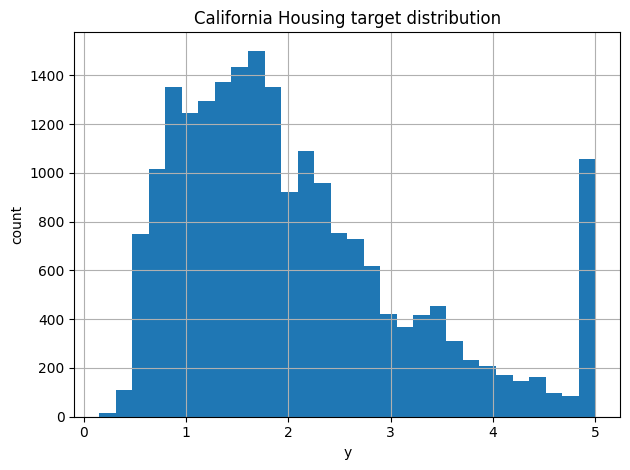

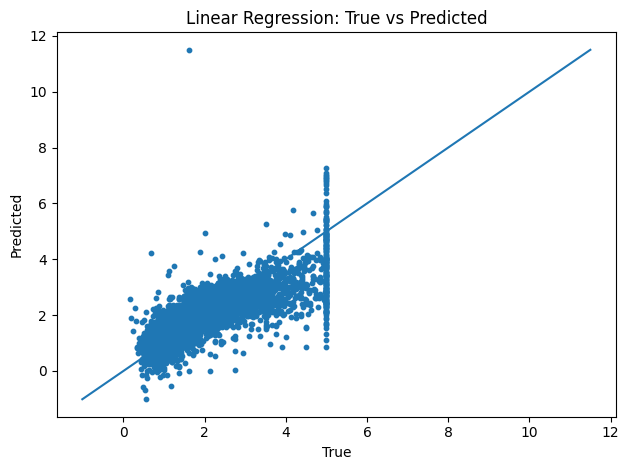

In [ ]:

import json, numpy as np, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.utils import Bunch

def load_dataset():
    try:
        from sklearn.datasets import fetch_california_housing
        ds=fetch_california_housing(as_frame=True)
        name="California Housing"
        X=ds.frame.drop(columns=[ds.target_names[0]])
        y=ds.frame[ds.target_names[0]]
        return Bunch(data=X,target=y,feature_names=list(X.columns),name=name)
    except Exception:
        from sklearn.datasets import load_diabetes
        ds=load_diabetes(as_frame=True)
        name="Diabetes (fallback)"
        X=ds.frame.drop(columns=["target"]); y=ds.frame["target"]
        return Bunch(data=X,target=y,feature_names=list(X.columns),name=name)

def quick_eda(X,y,name):
    print(f"Dataset: {name} | samples={len(X)} | features={len(X.columns)}")
    print("Head:\\n",X.head(3))
    print("Target stats: mean={:.3f} std={:.3f}".format(y.mean(),y.std()))
    plt.figure(); y.hist(bins=30)
    plt.title(f"{name} target distribution"); plt.xlabel("y"); plt.ylabel("count")
    plt.tight_layout(); plt.savefig("target_hist.png")

def build_and_eval(X,y,features):
    pre=ColumnTransformer([("num",StandardScaler(),features)],remainder="drop")
    pipe=Pipeline([("pre",pre),("lr",LinearRegression())])
    Xtr,Xte,ytr,yte=train_test_split(X,y,test_size=0.2,random_state=42)
    pipe.fit(Xtr,ytr); preds=pipe.predict(Xte)
    rmse=np.sqrt(mean_squared_error(yte,preds))
    mae=mean_absolute_error(yte,preds)
    print(f"RMSE: {rmse:.4f} | MAE: {mae:.4f}")
    plt.figure(); plt.scatter(yte,preds,s=10)
    plt.xlabel("True"); plt.ylabel("Predicted")
    plt.title("Linear Regression: True vs Predicted")
    lims=[min(yte.min(),preds.min()),max(yte.max(),preds.max())]
    plt.plot(lims,lims); plt.tight_layout(); plt.savefig("true_vs_pred.png")
    card={"model":"LinearRegression","dataset":"California Housing (fallback Diabetes)",
          "metrics":{"RMSE":rmse,"MAE":mae}}
    with open("model_card.json","w") as f: json.dump(card,f,indent=2)
    print("Saved: target_hist.png, true_vs_pred.png, model_card.json")
    return rmse,mae

if __name__=="__main__":
    ds=load_dataset()
    quick_eda(ds.data,ds.target,ds.name)
    build_and_eval(ds.data,ds.target,ds.feature_names)




Classification report (test):
              precision    recall  f1-score   support

         ham       0.97      1.00      0.98       966
        spam       1.00      0.77      0.87       149

    accuracy                           0.97      1115
   macro avg       0.98      0.89      0.93      1115
weighted avg       0.97      0.97      0.97      1115

Test accuracy: 0.9695


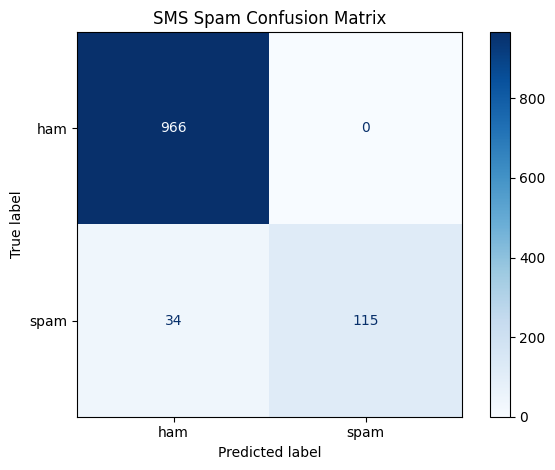

Saved: outputs/sms/cm_sms.png

Top 20 SPAM-indicative features:
txt                             4.305
mobile                          3.542
uk                              3.470
claim                           3.445
www                             3.276
reply                           3.066
stop                            3.025
free                            2.956
service                         2.832
150p                            2.718
prize                           2.561
text                            2.485
com                             2.431
50                              2.381
new                             2.233
won                             2.230
urgent                          2.189
cash                            2.147
win                             2.137
18                              2.015

Top 20 HAM-indicative features:
ok                             -1.931
ll                             -1.685
da                             -1.488
come                         

In [ ]:
# sms_spam_tfidf_logreg.py
# TF-IDF + Logistic Regression spam detector. Prints
# precision/recall/F1 and top positive/negative features.
# Saves confusion matrix figure.
#
# If offline: put the UCI "SMSSpamCollection" file (tab-separated "label<TAB>message")
# next to this script and set LOCAL_PATH below. Otherwise, the script tries a known URL.

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# Local path to the dataset (optional, used if the file is in the same directory)
LOCAL_PATH = "SMSSpamCollection"  # fallback local filename (optional)

# URL for remote dataset (used if local file is not found)
REMOTE_TSV = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/sms_spam_collection/SMSSpamCollection"

# Load the dataset
def load_data():
    # Try local UCI file; else try remote TSV; else raise an error
    if os.path.exists(LOCAL_PATH):
        df = pd.read_csv(LOCAL_PATH, sep="\t", header=None, names=["label", "message"])
        return df
    try:
        df = pd.read_csv(REMOTE_TSV, sep="\t", header=None, names=["label", "message"])
        return df
    except Exception as e:
        raise RuntimeError(
            "Could not load SMS dataset. Place 'SMSSpamCollection' next to this script "
            "or ensure internet is available."
        ) from e

# Main function for training the model and evaluating it
def main():
    # Create output directories
    os.makedirs("outputs/sms", exist_ok=True)

    # Load the data
    df = load_data()

    # Split into train and test sets
    X_train, X_test, y_train, y_test = train_test_split(
        df["message"].values, df["label"].values, test_size=0.2, random_state=42, stratify=df["label"].values
    )

    # TF-IDF Vectorizer: Convert text to feature vectors (unigrams and bigrams)
    vect = TfidfVectorizer(lowercase=True, stop_words="english", ngram_range=(1, 2), max_df=0.95, min_df=2)
    X_train_tfidf = vect.fit_transform(X_train)
    X_test_tfidf = vect.transform(X_test)

    # Logistic Regression classifier
    clf = LogisticRegression(penalty="l2", solver="liblinear", max_iter=1000)
    clf.fit(X_train_tfidf, y_train)

    # Predict on the test set
    y_pred = clf.predict(X_test_tfidf)

    # Print classification report and accuracy
    print("\nClassification report (test):")
    print(classification_report(y_test, y_pred, zero_division=0))
    print(f"Test accuracy: {accuracy_score(y_test, y_pred):.4f}")

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred, labels=["ham", "spam"])
    disp = ConfusionMatrixDisplay(cm, display_labels=["ham", "spam"])
    disp.plot(cmap="Blues")
    plt.title("SMS Spam Confusion Matrix")
    plt.tight_layout()
    plt.show()
    plt.savefig("outputs/sms/cm_sms.png", dpi=200)
    plt.close()
    print("Saved: outputs/sms/cm_sms.png")

    # Top positive/negative features (toward "spam")
    feature_names = np.array(vect.get_feature_names_out())
    # spam_idx = np.where(clf.classes_ == "spam")[0][0]
    # coefs = clf.coef_[spam_idx]
    coefs = clf.coef_[0]

    # Get top positive (spam-related) and negative (ham-related) features
    top_pos = np.argsort(coefs)[-20:][::-1]  # Top 20 positive (spam)
    top_neg = np.argsort(coefs)[:20]         # Top 20 negative (ham)

    # Print top 20 spam-indicative features
    print("\nTop 20 SPAM-indicative features:")
    for f, w in zip(feature_names[top_pos], coefs[top_pos]):
        print(f"{f:30s} {w: .3f}")

    # Print top 20 ham-indicative features
    print("\nTop 20 HAM-indicative features:")
    for f, w in zip(feature_names[top_neg], coefs[top_neg]):
        print(f"{f:30s} {w: .3f}")

# Entry point of the script
if __name__ == "__main__":
    main()


In [ ]:
# iris_logreg_svm.py
# Logistic Regression & Linear SVM on Iris with standardization,
# 5-fold CV, confusion matrices, per-class precision/recall, and PCA(2D) decision plots.

import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, precision_recall_fscore_support
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.decomposition import PCA

# Ensure output directory exists
def ensure_out():
    os.makedirs("outputs/iris", exist_ok=True)

# Print precision, recall, f1 score, and support for each class
def pr_table(y_true, y_pred, labels):
    p, r, f1, sup = precision_recall_fscore_support(y_true, y_pred, labels=labels, zero_division=0)
    header = f"{'class':>7} {'prec':>7} {'rec':>7} {'f1':>7} {'support':>8}"
    print(header)
    for c, pp, rr, ff, ss in zip(labels, p, r, f1, sup):
        print(f"{c:>7} {pp:7.3f} {rr:7.3f} {ff:7.3f} {ss:8d}")

# Plot the decision boundaries in 2D after applying PCA
def decision_plot_2d(model, X2d, y, title, fname, h=0.03):
    x_min, x_max = X2d[:, 0].min()-1, X2d[:, 0].max()+1
    y_min, y_max = X2d[:, 1].min()-1, X2d[:, 1].max()+1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    plt.figure()
    plt.contourf(xx, yy, Z, alpha=0.25)
    for c in np.unique(y):
        idx = (y == c)
        plt.scatter(X2d[idx, 0], X2d[idx, 1], s=20, edgecolors='k', label=str(c))
    plt.title(title)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(fname, dpi=200)
    plt.close()

def main():
    ensure_out()

    data = load_iris()
    X, y, names = data.data, data.target, data.target_names

    # Define pipeline for Logistic Regression
    pipe_lr = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(multi_class="multinomial", solver="lbfgs", max_iter=1000, n_jobs=-1))
    ])

    # Define pipeline for Linear SVM
    pipe_lsvm = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LinearSVC(C=1.0))
    ])

    # 5-fold cross-validation
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    # Iterate over models (Logistic Regression and Linear SVM)
    for label, model in [("Logistic Regression", pipe_lr), ("Linear SVM", pipe_lsvm)]:
        # Perform cross-validation and compute accuracy
        scores = cross_val_score(model, X, y, cv=cv, scoring="accuracy")
        print(f"{label} 5-fold CV accuracy: {scores.mean():.4f} ± {scores.std():.4f}")

        # Get predictions
        y_pred = cross_val_predict(model, X, y, cv=cv)

        # Confusion matrix and per-class metrics
        cm = confusion_matrix(y, y_pred)
        print(f"\n{label} per-class metrics:")
        pr_table(y, y_pred, labels=[0, 1, 2])
        print("\nClassification report:")
        print(classification_report(y, y_pred, target_names=names, zero_division=0))

        # Plot confusion matrix
        disp = ConfusionMatrixDisplay(cm, display_labels=names)
        disp.plot(cmap="Blues", xticks_rotation=45)
        plt.title(f"Iris Confusion Matrix - {label}")
        out = f"outputs/iris/cm_{label.replace(' ', '_').lower()}.png"
        plt.tight_layout()
        plt.savefig(out, dpi=200)
        plt.close()
        print(f"Saved: {out}")

    # PCA(2D) visualization models (trained on 2D only for plotting)
    X2d = PCA(n_components=2, random_state=42).fit_transform(X)

    # Logistic Regression on 2D data
    lr2d = LogisticRegression(multi_class="multinomial", solver="lbfgs", max_iter=1000).fit(X2d, y)
    decision_plot_2d(lr2d, X2d, y, "Iris Decision Regions (PCA) - LogReg", "outputs/iris/decision_lr.png")

    # Linear SVM on 2D data
    lsvm2d = LinearSVC(C=1.0).fit(X2d, y)
    decision_plot_2d(lsvm2d, X2d, y, "Iris Decision Regions (PCA) - LinearSVM", "outputs/iris/decision_lsvm.png")

if __name__ == "__main__":
    main()


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and wi

Logistic Regression 5-fold CV accuracy: 0.9533 ± 0.0452

Logistic Regression per-class metrics:
  class    prec     rec      f1  support
      0   1.000   1.000   1.000       50
      1   0.922   0.940   0.931       50
      2   0.939   0.920   0.929       50

Classification report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        50
  versicolor       0.92      0.94      0.93        50
   virginica       0.94      0.92      0.93        50

    accuracy                           0.95       150
   macro avg       0.95      0.95      0.95       150
weighted avg       0.95      0.95      0.95       150

Saved: outputs/iris/cm_logistic_regression.png
Linear SVM 5-fold CV accuracy: 0.9267 ± 0.0533

Linear SVM per-class metrics:
  class    prec     rec      f1  support
      0   1.000   0.980   0.990       50
      1   0.898   0.880   0.889       50
      2   0.885   0.920   0.902       50

Classification report:
              precisio

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


In [ ]:
# svm_kernels_margins_digits.py
# Digits dataset: Linear vs RBF SVM with grid search over (C, gamma),
# support-vector visualization (in PCA 2D), and accuracy heatmap.

import os
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_score, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.decomposition import PCA


def ensure_out():
    os.makedirs("outputs/svm", exist_ok=True)


def heatmap(Z, Cs, gammas, title, fname):
    plt.figure()
    im = plt.imshow(Z, origin="lower", aspect="auto")
    plt.colorbar(im, label="CV Accuracy")
    plt.xticks(np.arange(len(gammas)), gammas)
    plt.yticks(np.arange(len(Cs)), Cs)
    plt.xlabel("gamma")
    plt.ylabel("C")
    plt.title(title)
    plt.tight_layout()
    plt.savefig(fname, dpi=200)
    plt.close()


def plot_sv_2d(clf, X2d, y, title, fname):
    plt.figure()

    # plot points
    for c in np.unique(y):
        idx = (y == c)
        plt.scatter(
            X2d[idx, 0], X2d[idx, 1],
            s=10, edgecolors='k', alpha=0.6, label=str(c)
        )

    # support vectors
    sv = clf.support_vectors_
    plt.scatter(
        sv[:, 0], sv[:, 1],
        s=60, facecolors='none', edgecolors='r',
        linewidths=1.5, label="Support Vectors"
    )

    plt.title(title)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.legend(loc="best", fontsize=7, ncol=2)
    plt.tight_layout()
    plt.savefig(fname, dpi=200)
    plt.close()


def main():
    ensure_out()

    X, y = load_digits(return_X_y=True)

    scaler = StandardScaler()
    Xs = scaler.fit_transform(X)

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    # Baselines
    lin = SVC(kernel="linear", C=1.0)  # using SVC to access support_vectors_
    rbf = SVC(kernel="rbf", C=1.0, gamma="scale")

    lin_scores = cross_val_score(lin, Xs, y, cv=cv, scoring="accuracy")
    rbf_scores = cross_val_score(rbf, Xs, y, cv=cv, scoring="accuracy")

    print(f"Linear SVM CV accuracy: {lin_scores.mean():.4f} ± {lin_scores.std():.4f}")
    print(f"RBF SVM CV accuracy: {rbf_scores.mean():.4f} ± {rbf_scores.std():.4f}")

    # Grid over C and gamma for RBF
    param_grid = {
        "C": [0.1, 1, 10, 100],
        "gamma": [1e-3, 1e-2, 1e-1, 1.0]
    }

    grid = GridSearchCV(
        SVC(kernel="rbf"),
        param_grid=param_grid,
        cv=cv,
        scoring="accuracy",
        n_jobs=-1,
        return_train_score=False
    )

    grid.fit(Xs, y)

    print(f"Best RBF params: {grid.best_params_}, best CV accuracy: {grid.best_score_:.4f}")

    means = grid.cv_results_["mean_test_score"].reshape(
        len(param_grid["C"]),
        len(param_grid["gamma"])
    )

    heatmap(
        means,
        param_grid["C"],
        param_grid["gamma"],
        "RBF SVM Grid Search Accuracy",
        "outputs/svm/heatmap_rbf.png"
    )

    print("Saved: outputs/svm/heatmap_rbf.png")

    # Visualize support vectors in PCA 2D (train split)
    Xtr, Xte, ytr, yte = train_test_split(
        Xs, y, test_size=0.25, stratify=y, random_state=42
    )

    pca = PCA(n_components=2, random_state=42)
    Xtr2 = pca.fit_transform(Xtr)

    lin2 = SVC(kernel="linear", C=1.0).fit(Xtr2, ytr)
    rbf2 = SVC(
        kernel="rbf",
        C=grid.best_params_["C"],
        gamma=grid.best_params_["gamma"]
    ).fit(Xtr2, ytr)

    plot_sv_2d(
        lin2, Xtr2, ytr,
        "Digits: Linear SVM Support Vectors (PCA-2D train)",
        "outputs/svm/sv_linear.png"
    )

    plot_sv_2d(
        rbf2, Xtr2, ytr,
        "Digits: RBF SVM Support Vectors (PCA-2D train)",
        "outputs/svm/sv_rbf.png"
    )

    print("Saved: outputs/svm/sv_linear.png, outputs/svm/sv_rbf.png")


if __name__ == "__main__":
    main()


Linear SVM CV accuracy: 0.9794 ± 0.0033
RBF SVM CV accuracy: 0.9839 ± 0.0060
Best RBF params: {'C': 10, 'gamma': 0.01}, best CV accuracy: 0.9827
Saved: outputs/svm/heatmap_rbf.png
Saved: outputs/svm/sv_linear.png, outputs/svm/sv_rbf.png
